In [ ]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import os

#save image function
def save_detector_image(img, outpath):
    fig, ax = plt.subplots(figsize=(4.5, 4.0))
    im = ax.imshow(img.T, cmap='inferno', origin='lower')
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Counts', fontsize=10)
    cbar.ax.tick_params(labelsize=9)
    ax.set_xlabel("Detector X", fontsize=11)
    ax.set_ylabel("Detector Y", fontsize=11)
    ax.tick_params(labelsize=9)
    ax.set_xticks(np.arange(0, detector.num_bins, 5))
    ax.set_yticks(np.arange(0, detector.num_bins, 5))
    plt.tight_layout()
    plt.savefig(outpath, dpi=300, bbox_inches='tight')
    plt.close()


#detector class
class Detector:
    def __init__(self, plane_size, detector_distance, num_bins, sigma=0, axis=2, detector_eff=1.0):
        self.plane_size = plane_size
        self.distance = detector_distance
        self.num_bins = num_bins
        self.sigma = sigma
        self.axis = axis
        self.detector_eff = detector_eff


#project ion trajectories onto detector
def bin_plane_zaxis(xyz, detector, mass=None, mass_filter=None):
    # Optional mass filtering
    if mass is not None and mass_filter is not None:
        mass = np.array(mass)
        idx = (mass > mass_filter[0]) & (mass < mass_filter[1])
        xyz = xyz[idx]

    disp = xyz

    # Only ions moving toward the detector (along +z)
    L = detector.distance
    mask_dir = (disp[:, 2] > 0) if L > 0 else (disp[:, 2] < 0)
    disp = disp[mask_dir]

    if disp.shape[0] == 0:
        return np.zeros((detector.num_bins, detector.num_bins))

    # Geometric projection onto detector plane
    k = L / disp[:, 2]
    x = disp[:, 0] * k
    y = disp[:, 1] * k
    

    # Bin edges
    edges = np.linspace(-detector.plane_size / 2,
                         detector.plane_size / 2,
                         detector.num_bins + 1)

    bins, _, _ = np.histogram2d(x, y, bins=[edges, edges])

    # Optional detector efficiency
    if detector.detector_eff < 1.0:
        bins = np.random.binomial(bins.astype(int), detector.detector_eff)

    return bins


#rmsd calculation + save mean detector images
def calculate_detector_rmsd(base_path, detector, dataset_name="Data", simulation_type="intensity"):

    if not os.path.exists(base_path):
        print(f"ERROR: Directory {base_path} does not exist!")
        return None

    print(f"\nProcessing: {dataset_name}")

    detector_images_by_parameter = {}

    # Folder for saving detector patterns
    patterns_dir = os.path.join(base_path, f"detector_patterns_{dataset_name}")
    os.makedirs(patterns_dir, exist_ok=True)

    # Determine directory prefix and parser
    if simulation_type == "intensity":
        dir_prefix = "I_"
        def parse_value(dirname):
            return float(dirname.split("_")[1])
    elif simulation_type == "duration":
        dir_prefix = "dur_"
        def parse_value(dirname):
            return float(dirname.split("_")[1].replace("fs", ""))
    else:
        raise ValueError("simulation_type must be 'intensity' or 'duration'")

    # Loop over intensity/duration folders
    for idir in sorted(os.listdir(base_path)):
        ipath = os.path.join(base_path, idir)

        if not idir.startswith(dir_prefix):
            continue

        try:
            parameter_value = parse_value(idir)
        except Exception:
            continue

        if parameter_value not in detector_images_by_parameter:
            detector_images_by_parameter[parameter_value] = []

        if not os.path.isdir(ipath):
            continue

        # Loop over replicas
        for rep in sorted(os.listdir(ipath)):
            rep_path = os.path.join(ipath, rep)
            if not os.path.isdir(rep_path):
                continue

            h5_file = os.path.join(rep_path, "results.h5")
            if not os.path.exists(h5_file):
                continue

    # Save mean detector pattern for each parameter value
    for param_value, images in detector_images_by_parameter.items():
        if len(images) == 0:
            continue
        mean_img = np.mean(images, axis=0)
        fname = f"{dataset_name}_{simulation_type}_{param_value:g}_mean.png"
        outpath = os.path.join(patterns_dir, fname)
        save_detector_image(mean_img, outpath)
        print(f"  Saved mean pattern: {fname}")


    results = {
        'parameters': [],
        'detector_rmsd': [],
        'n_nonempty_bins': []
    }

    for param_value in sorted(detector_images_by_parameter.keys()):
        images = detector_images_by_parameter[param_value]

        if len(images) < 2:
            continue

        images_array = np.array(images)
        mean_img = np.mean(images_array, axis=0)

        # Mask: only bins with non-zero mean
        mask = mean_img > 0
        n_nonempty = np.sum(mask)

        if n_nonempty > 0:
            per_bin_rmsd = np.sqrt(np.mean((images_array - mean_img) ** 2, axis=0))
            detector_rmsd = np.mean(per_bin_rmsd[mask])
        else:
            detector_rmsd = 0.0

        results['parameters'].append(param_value)
        results['detector_rmsd'].append(detector_rmsd)
        results['n_nonempty_bins'].append(n_nonempty)

    for key in results:
        results[key] = np.array(results[key])

    return results


#main function
if __name__ == "__main__":

    detector = Detector(
        plane_size=120,
        detector_distance=20,
        num_bins=20,
        sigma=0,
        axis=2,           # z-axis projection
        detector_eff=1.0
    )

    #intensity simulations
    intensity_datasets = {
        'Homogeneous':   '/home/wilma/harryshouse/output_data/intensityvar_homogen',
        'Heterogeneous': '/home/wilma/harryshouse/output_data/intensityvar_heterogen'
    }

    intensity_results = {}
    for name, path in intensity_datasets.items():
        results = calculate_detector_rmsd(path, detector, dataset_name=name, simulation_type="intensity")
        if results is not None:
            intensity_results[name] = results

   #duration
    duration_datasets = {
        'Homogeneous':   '/home/wilma/harryshouse/output_data/duration_2MS2',
        'Heterogeneous': '/home/wilma/harryshouse/output_data/diff_structures_duration'
    }

    duration_results = {}
    for name, path in duration_datasets.items():
        if os.path.exists(path):
            results = calculate_detector_rmsd(path, detector, dataset_name=name, simulation_type="duration")
            if results is not None:
                duration_results[name] = results

    #plots
    colors  = {'Homogeneous': '#003a7d', 'Heterogeneous': '#008dff'}
    markers = {'Homogeneous': 'o',       'Heterogeneous': 's'}

    # Intensity rmsd
    if intensity_results:
        fig, ax = plt.subplots(figsize=(10, 8))
        for name, results in intensity_results.items():
            ax.plot(results['parameters'], results['detector_rmsd'],
                    marker=markers[name], color=colors[name], label=name,
                    linewidth=2, markersize=8, alpha=0.8)
        ax.set_xscale('log')
        ax.set_xlabel('Intensity (number of photons)', fontsize=17)
        ax.set_ylabel('Detector RMSD (counts/bin)', fontsize=17)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=14)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('detector_rmsd_vs_intensity.png', dpi=300, bbox_inches='tight')
        print("\nSaved: detector_rmsd_vs_intensity.png")

    # Duration rmsd
    if duration_results:
        fig, ax = plt.subplots(figsize=(10, 8))
        for name, results in duration_results.items():
            ax.plot(results['parameters'], results['detector_rmsd'],
                    marker=markers[name], color=colors[name], label=name,
                    linewidth=2, markersize=8, alpha=0.8)
        ax.set_xlabel('Pulse Duration (fs)', fontsize=17)
        ax.set_ylabel('Detector RMSD (counts/bin)', fontsize=17)
        ax.tick_params(labelsize=13)
        ax.legend(fontsize=14)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig('detector_rmsd_vs_duration.png', dpi=300, bbox_inches='tight')
        print("Saved: detector_rmsd_vs_duration.png")

    plt.show()

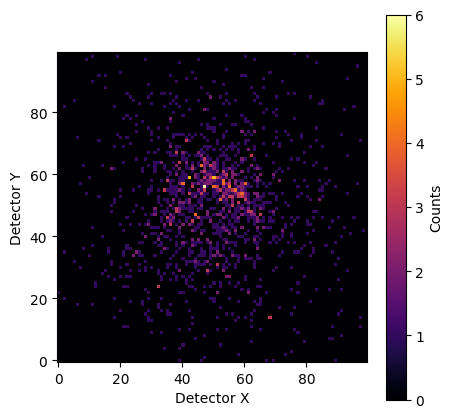

In [ ]:
import h5py

#file you want detector image from
h5_file = "/home/wilma/harryshouse/output_data/intensityvar_heterogen/I_7.85e+11/replica_07/results.h5"

with h5py.File(h5_file, "r") as f:
    disp = f["displacement"][:]
    mass = f["mass"][:]

# Create detector image 
img = bin_plane_zaxis(
    disp,
    detector
)
#plot image
plt.figure(figsize=(5, 5))
plt.imshow(img.T, cmap="inferno", origin="lower")
plt.colorbar(label="Counts")
plt.xlabel("Detector X")
plt.ylabel("Detector Y")
plt.show()